<a href="https://colab.research.google.com/github/ShreyaKantamsetty/bank-campaign-prediction/blob/main/notebooks/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup


In [1]:
!pip install imbalanced-learn xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

#Data Load

In [2]:
from google.colab import files
uploaded = files.upload()

Saving bank-additional-full.csv to bank-additional-full.csv


In [3]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


#Step 1: Explore and Clean

**Basic shape ,target balance**

In [5]:
print(df.shape)
print(df['y'].value_counts(normalize=True)*100)

(41188, 21)
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


**Shape:** 41,188 rows, 20 features + target `y`

**Target balance:** ~89% no, ~11% yes (imbalanced)

**Dtypes + unknowns**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

**Numerical features**:
age, duration, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed

**Categorical features**:
job, marital, education, default, housing, loan, contact, month, day of week, poutcome

In [7]:
# To check in every categorical column how many times 'unknown' has occured
for col in df.select_dtypes(include='object').columns:
    if 'unknown' in df[col].unique():
        print(col, ':', (df[col] == 'unknown').sum(),
              f"({round((df[col] == 'unknown').mean()*100, 2)}%)")

job : 330 (0.8%)
marital : 80 (0.19%)
education : 1731 (4.2%)
default : 8597 (20.87%)
housing : 990 (2.4%)
loan : 990 (2.4%)


In [8]:
# Are housing and loan unknowns the same clients?
(df['housing'] == 'unknown').equals(df['loan'] == 'unknown')

True

In [9]:
pd.crosstab(df['default'], df['y'], normalize='index')

y,no,yes
default,,
no,0.87121,0.12879
unknown,0.94847,0.05153
yes,1.00000,0.00000


**Unknown value analysis:**
- default: 8,597 (20.87%) — high proportion, likely non-disclosure
- education: 1,731 (4.20%)
- housing: 990 (2.40%)
- loan: 990 (2.40%)
- job: 330 (0.80%)
- marital: 80 (0.19%)

Confirmed: housing and loan 'unknown' values occur in the exact same 990 rows — these clients declined to answer both loan-related questions together.

Decision: keep 'unknown' as its own category during encoding (not imputed), since non-disclosure may itself carry predictive signal, especially for `default` given its high rate.

Verified: default=unknown subscribes at 5.15% vs. default=no at 12.88% — this comparison has large enough samples (8,597 vs. ~32,000) to be meaningful. The default=yes category was excluded from this comparison due to very small sample size, making its rate unreliable.

**Unusual Values**

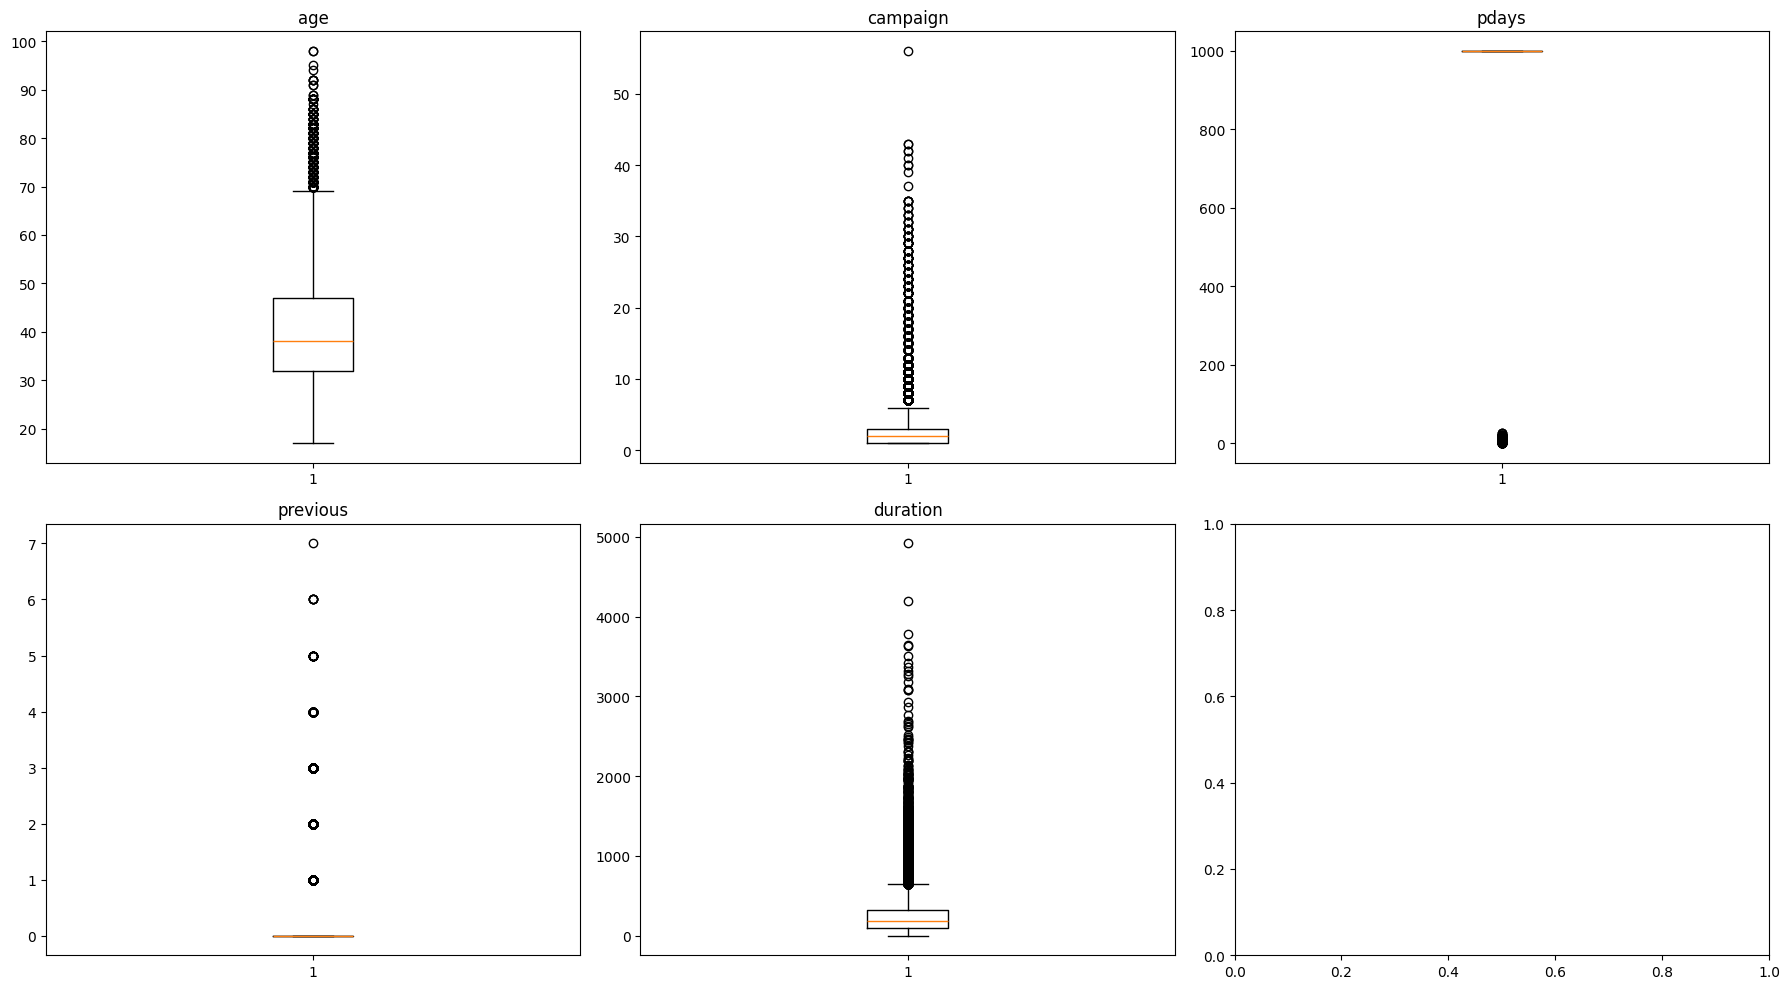

In [10]:
numeric_cols = ['age', 'campaign', 'pdays', 'previous', 'duration']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [11]:
for col in ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']:
    print(col, ':', df[col].nunique(), 'unique values')

emp.var.rate : 10 unique values
cons.price.idx : 26 unique values
cons.conf.idx : 26 unique values
euribor3m : 316 unique values
nr.employed : 11 unique values


**Outliers:** age, campaign, duration all show genuine extreme values (not data errors) — e.g. campaign up to 56 contacts, duration up to ~4900s. No removal needed; tree-based models are robust to these. Economic indicator columns (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed) have very few unique values (10–316) — they're time-period markers, not per-client features, so not boxplotted individually.

In [12]:
df[df['pdays'] != 999]['pdays'].describe()

,pdays
count,1515.000000
mean,6.014521
std,3.824906
min,0.000000
25%,3.000000
50%,6.000000
75%,7.000000
max,27.000000


In [13]:
print(pd.crosstab((df['pdays'] != 999).astype(int),df['previous'] > 0))

previous  False  True 
pdays                 
0         35563   4110
1             0   1515


pdays = 999 does not reliably mean 'never contacted'. 4110 training rows have previous > 0 but pdays = 999, so I treat 999 as 'gap not recorded'. Contact history is carried by previous and poutcome.



In [14]:
df[['age', 'campaign', 'previous', 'duration']].describe()

,age,campaign,previous,duration
count,41188.00000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,0.172963,258.285010
std,10.42125,2.770014,0.494901,259.279249
min,17.00000,1.000000,0.000000,0.000000
25%,32.00000,1.000000,0.000000,102.000000
50%,38.00000,2.000000,0.000000,180.000000
75%,47.00000,3.000000,0.000000,319.000000
max,98.00000,56.000000,7.000000,4918.000000


No negative or impossible values found in numeric columns (age: 17–98, duration: 0–4918, campaign: 1–56, previous: 0–7 — all valid ranges)

In [15]:
df.duplicated().sum()

np.int64(12)

In [16]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(41176, 21)

12 exact duplicate rows found (0.03% of data) and removed

In [17]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())

job ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
marital ['married' 'single' 'divorced' 'unknown']
education ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
default ['no' 'unknown' 'yes']
housing ['no' 'yes' 'unknown']
loan ['no' 'yes' 'unknown']
contact ['telephone' 'cellular']
month ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week ['mon' 'tue' 'wed' 'thu' 'fri']
poutcome ['nonexistent' 'failure' 'success']
y ['no' 'yes']


Categorical columns checked for inconsistent labeling (typos, case mismatches) — none found; all categories are clean and as expected.


**Relevant Relationships**

In [18]:
# Check how poutcome(outcome of the last campaign) effects y
pd.crosstab(df['poutcome'], df['y'], normalize='index')

y,no,yes
poutcome,,
failure,0.857714,0.142286
nonexistent,0.911676,0.088324
success,0.348871,0.651129


In [19]:
# month v/s y (seasonality)
pd.crosstab(df['month'], df['y'], normalize='index').sort_values('yes', ascending=False)

y,no,yes
month,,
mar,0.494505,0.505495
dec,0.510989,0.489011
sep,0.550877,0.449123
oct,0.560669,0.439331
apr,0.795135,0.204865
aug,0.893944,0.106056
jun,0.894885,0.105115
nov,0.898537,0.101463
jul,0.909611,0.090389


In [20]:
# previous contact v/s y
df.groupby('y')['previous'].mean()

,previous
y,
no,0.132414
yes,0.492779


In [21]:
pd.crosstab(df['job'], df['y'], normalize='index').sort_values('yes', ascending=False)

y,no,yes
job,,
student,0.685714,0.314286
retired,0.747381,0.252619
unemployed,0.857988,0.142012
admin.,0.870333,0.129667
management,0.887825,0.112175
unknown,0.887879,0.112121
technician,0.891675,0.108325
self-employed,0.895144,0.104856
housemaid,0.900000,0.100000


**Key relationships found:**
- `poutcome`: success → 65% subscribe vs. 9–14% for failure/nonexistent — strongest signal so far
- `month`: strong seasonality — mar/dec/sep/oct high (40–50%), may/jun/aug/jul/nov low (6–13%)
- `previous`: subscribers average 0.49 vs. non-subscribers 0.13
- `job`: Students and retired people are more likely to subscribe

<Axes: >

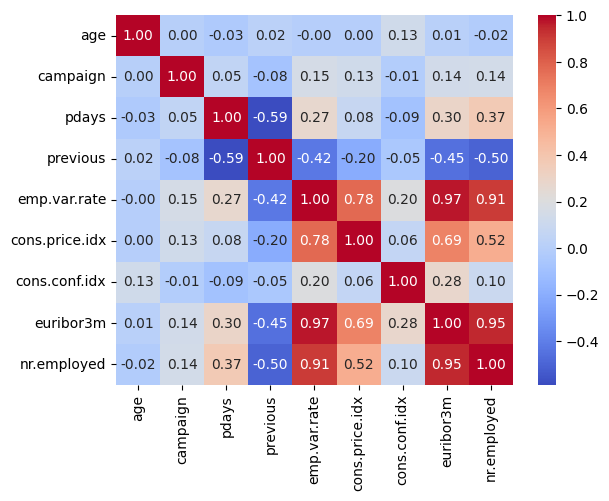

In [22]:
numeric_cols = ['age', 'campaign', 'pdays', 'previous',
                 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

Multivariate Feature Correlation Check

**Why this was done:** To check whether any numeric features were highly correlated with each other (redundant), since this can cause instability in coefficient-based models (Logistic Regression, LDA, QDA), even though it doesn't affect tree-based models. This was a diagnostic check, not intended to drive feature removal for the tree-based candidates.

**Method:** Pearson correlation heatmap on all numeric columns.

**Findings:**
- The four economic indicators — `emp.var.rate`, `cons.price.idx`, `euribor3m`, `nr.employed` — are strongly correlated with each other (r = 0.78–0.97), since they all reflect overall economic conditions at the time of contact.
- `cons.conf.idx` is comparatively independent of the other economic indicators (r = 0.06–0.28).
- `previous` and `pdays` show a moderate negative correlation (r = -0.59) — more past contacts tends to mean more recent contact, which is expected.
- `age` and `campaign` show negligible correlation with other features.

**Decision:** All features were retained. Random Forest and Boosting (the final candidate models) are not sensitive to multicollinearity, so redundancy among the economic indicators does not need to be resolved for them. This correlation is noted here because it likely contributes to the instability seen in LDA/QDA (Section: Required Algorithm Studies), and would be revisited (e.g., dropping `euribor3m`/`nr.employed` in favor of `emp.var.rate`) only if a coefficient-based model were selected as final.



**Flags for feature audit (next step):**
- `duration` — excludes (post-call leakage)
- `campaign` — mild leakage concern (counts current call); consider `campaign - 1`
- `pdays`, `previous`, `poutcome` — safe, pre-call history

# Step 2: Build safe preprocessing

 Feature Engineering:

In [23]:
df = df.drop(columns=['duration'])
df.shape

(41176, 20)

In [24]:
df['pdays_recorded'] = (df['pdays'] != 999).astype(int)
df['pdays_clean'] = df['pdays'].replace(999, 0)
df = df.drop(columns=['pdays'])

In [25]:
df.shape

(41176, 21)

In [26]:
df['campaign'] = df['campaign'] - 1

Feature engineering decisions

| Change | Reason |
|---|---|
| Dropped `duration` | It is the length of the current call, so it is only known after the call. The bank chooses whom to call before the call starts, so using it would leak the outcome. |
| `campaign` → `campaign - 1` | `campaign` includes the current contact. Subtracting 1 gives the number of earlier contacts in this campaign. This is an assumption based on the UCI definition. I will test a run without `campaign` as a sensitivity check. |
| `pdays` → `pdays_clean` + `pdays_recorded` | `pdays = 999` is a placeholder. I replaced it with 0 in `pdays_clean` and added a 0/1 flag `pdays_recorded` so the model can tell a real 0 (same-day contact) from a placeholder. |

All of these transformations work row by row and learn nothing from the data, so applying them before the split leaks nothing.

In [27]:
contacted_subset = df[df['pdays_recorded'] == 1]
contacted_subset[['pdays_clean', 'previous']].corr()

,pdays_clean,previous
pdays_clean,1.000000,-0.040022
previous,-0.040022,1.000000


Correction: An initial correlation check between raw pdays and previous showed r = -0.59, but this was confounded by the placeholder value pdays=999 (never contacted), which dominates ~96% of rows and creates a spurious pattern. Recomputing among only previously-contacted clients (pdays_clean, previous) shows r = -0.04 — effectively no relationship. The original interpretation ("more prior contacts means more recent contact") does not hold; days-since-last-contact and total-contact-count are independent among repeat-contacted clients.

Time-based train/holdout split (do this BEFORE fitting any pipeline)

In [28]:
n = len(df)
split_idx = int(n * 0.8)

train_df = df.iloc[:split_idx].reset_index(drop=True)
holdout_df = df.iloc[split_idx:].reset_index(drop=True)

print(train_df.shape, holdout_df.shape)

(32940, 21) (8236, 21)


Separate features and target

In [29]:
X_train = train_df.drop(columns=['y'])
y_train = train_df['y'].map({'no': 0, 'yes': 1})

X_holdout = holdout_df.drop(columns=['y'])
y_holdout = holdout_df['y'].map({'no': 0, 'yes': 1})

Time-based split and pipeline

- The file is ordered by date, so I split by position: the first 80% of rows (32,940) for training and the last 20% (8,236) reserved as a final holdout.
- The holdout is not used for exploration, tuning or model choice. It is scored once, at the end.
- The `ColumnTransformer` is the first step of a `Pipeline`, so scaling and encoding are fitted on training rows only, and cross-validation refits them inside each fold.
- Limitation: my EDA earlier in this notebook used all rows, including the later holdout. Nothing was fitted on it, but further exploration uses `train_df` only.

Define column groups for ColumnTransformer

In [30]:
numeric_cols = ['age', 'campaign', 'previous', 'pdays_clean',
                 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

binary_cols = ['pdays_recorded']

categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                     'contact', 'month', 'day_of_week', 'poutcome']

Build the ColumnTransformer + Pipeline

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('bin', 'passthrough', binary_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
])

- `handle_unknown='ignore'` in the encoder means a category not seen in training is encoded as all zeros instead of raising an error.

- **Categorical columns** (`job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome`) use one-hot encoding. These are nominal categories with no reliable numeric order. `sparse_output=False` gives a dense array, which LDA and QDA require.
- **Numeric columns** use `StandardScaler`. It matters for logistic regression, LDA, QDA, clustering and PCA, which depend on feature scale, and it does no harm to tree models.
- **`pdays_recorded`** is already 0/1, so it passes through unscaled.
- `campaign` and `previous` are right-skewed. I have not log-transformed them yet. I will test `log1p` followed by scaling as an experiment for the coefficient-based models.
- **Economic indicators** (`emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed`) stay in for now. They mostly identify the time period rather than the client, so I keep them in `econ_cols` and will run a with/without comparison.

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier

econ_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Pipeline skeleton that every model will reuse
pipe = Pipeline([('prep', preprocess), ('clf', DummyClassifier(strategy='prior'))])
pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign',
                                                   'previous', 'pdays_clean',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('bin', 'passthrough',
                                                  ['pdays_recorded']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('clf', DummyClassifier())])

**Sanity check:** fitting the preprocessing on the training set gives 32,940 rows × 62 columns with 0 NaNs, and the feature names show scaling, passthrough and one-hot encoding applied to the intended columns. This was a smoke test to confirm the pipeline runs before modelling.

In [33]:
cat_enc = pipe.named_steps['prep'].named_transformers_['cat']
print({c: len(cats) for c, cats in zip(categorical_cols, cat_enc.categories_)})

{'job': 12, 'marital': 4, 'education': 8, 'default': 3, 'housing': 3, 'loan': 3, 'contact': 2, 'month': 9, 'day_of_week': 5, 'poutcome': 3}


In [34]:
all_months = ['may','jun','jul','aug','oct','nov','dec','mar','apr','sep']
print(set(all_months) - set(X_train['month']))

{'sep'}


Training data yields 62 encoded columns rather than 63 because `month` has 9 categories in the training rows: `sep` does not appear in the first 80% of the file, so all September records fall in the holdout. Rows with an unseen category are encoded as all zeros (`handle_unknown='ignore'`), so the pipeline will not fail, but the model cannot learn September's effect from training. Limitation: results on holdout records from September should be read with this in mind.

# Step 3: Establish baselines



## Initial Baselines

Goal: compare a constant baseline, logistic regression, and two further model families (a bagging ensemble and a boosting method) under identical conditions, using time-ordered cross-validation on the training rows only.

**Imports and Settings**

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import make_scorer, f1_score

RANDOM_STATE = 42  # fixed seed so results are reproducible

**Define the cross-validation scheme and inspect the folds**

In [36]:
# Each fold trains on EARLIER rows and validates on the NEXT block of rows,
# which mimics "train on the past, predict the future".
tscv = TimeSeriesSplit(n_splits=5)

print("Overall training positive rate:", round(y_train.mean(), 3))
for i, (tr, va) in enumerate(tscv.split(X_train), start=1):
    print(f"Fold {i}: train rows = {len(tr):>6} | validation rows = {len(va):>5} | "
          f"validation positive rate = {y_train.iloc[va].mean():.3f}")

Overall training positive rate: 0.064
Fold 1: train rows =   5490 | validation rows =  5490 | validation positive rate = 0.039
Fold 2: train rows =  10980 | validation rows =  5490 | validation positive rate = 0.060
Fold 3: train rows =  16470 | validation rows =  5490 | validation positive rate = 0.059
Fold 4: train rows =  21960 | validation rows =  5490 | validation positive rate = 0.054
Fold 5: train rows =  27450 | validation rows =  5490 | validation positive rate = 0.140


CV scheme:

 the file is date-ordered, so I use `TimeSeriesSplit` (5 folds) inside the training rows. Each fold trains on earlier records and validates on the next block, so no model is validated on data older than what it trained on. The holdout is not used anywhere in this step. Note the first fold trains on only ~1/6 of the data, so its scores are expected to be noisier. The positive rate differs between folds, which reflects drift over time.

Observation:

The subscription rate drifts over time.The overall training positive rate is 6.4%. The validation positive rate by fold is 3.9%, 6.0%, 5.9%, 5.4% and 14.0%. The rate is fairly flat for four folds, then jumps sharply in the last, most recent block of training records.

**Possible reasons (not tested here):** changes in the economic environment over the file's time span, changes in who was contacted or when, or seasonal effects. The dataset has no field that lets me confirm any single cause, so I treat this as unexplained drift.

**How this affects the comparison:**
- PR-AUC depends on the base rate, so the same PR-AUC means different things in different folds. I will compare each model with the dummy baseline within the same fold (a ratio above 1.0 means it beats the base rate) rather than only averaging PR-AUC across folds.
- ROC-AUC has a floor of 0.5 whatever the base rate, so I use it as the steadier headline metric.
- Accuracy is dominated by the "no" class (always saying "no" gets about 94% on this data), so it is not used to compare models.


**Define the candidate models**

In [37]:
models = {
    # Majority-class baseline: always predicts "no" (hard 0/1 output)
    'dummy_majority_class': DummyClassifier(strategy='most_frequent'),

    'logistic_regression': LogisticRegression(max_iter=1000),

    'random_forest': RandomForestClassifier(n_estimators=300, min_samples_leaf=5,random_state=RANDOM_STATE, n_jobs=-1),

    'gradient_boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

**Run the cross-validation**

In [38]:
scoring = {
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score, zero_division=0),
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
}

cv_results = {}
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocess), ('clf', clf)])
    cv_results[name] = cross_validate(pipe, X_train, y_train, cv=tscv, scoring=scoring, return_train_score=False)
    print("done:", name)

done: dummy_majority_class
done: logistic_regression
done: random_forest
done: gradient_boosting


In [39]:
print(cv_results)

{'dummy_majority_class': {'fit_time': array([0.07595134, 0.1125288 , 0.13736439, 0.31950402, 0.71463513]), 'score_time': array([0.18112755, 0.10707569, 0.26906347, 0.1363306 , 0.41687775]), 'test_accuracy': array([0.96120219, 0.93952641, 0.94080146, 0.94553734, 0.85974499]), 'test_f1': array([0., 0., 0., 0., 0.]), 'test_roc_auc': array([0.5, 0.5, 0.5, 0.5, 0.5]), 'test_pr_auc': array([0.03879781, 0.06047359, 0.05919854, 0.05446266, 0.14025501])}, 'logistic_regression': {'fit_time': array([0.55015445, 0.64070368, 0.60950541, 0.543962  , 0.70067763]), 'score_time': array([0.17701817, 0.31069994, 0.14895725, 0.18624663, 0.17319393]), 'test_accuracy': array([0.6428051 , 0.93952641, 0.94080146, 0.94553734, 0.85974499]), 'test_f1': array([0.07193564, 0.        , 0.        , 0.        , 0.        ]), 'test_roc_auc': array([0.5287909 , 0.56600578, 0.49597587, 0.44670767, 0.65382016]), 'test_pr_auc': array([0.03972954, 0.07287245, 0.06122767, 0.05136874, 0.20274661])}, 'random_forest': {'fit_ti

**Summary table (mean over folds)**

In [40]:
rows = {}
for name, res in cv_results.items():
    rows[name] = {
        'accuracy':   res['test_accuracy'].mean(),
        'f1':         res['test_f1'].mean(),
        'roc_auc':    res['test_roc_auc'].mean(),
        'pr_auc':     res['test_pr_auc'].mean(),
        'fit_time_s': res['fit_time'].mean(),
    }

summary = pd.DataFrame(rows).T.round(3)
summary = summary.sort_values('pr_auc', ascending=False)
summary

,accuracy,f1,roc_auc,pr_auc,fit_time_s
random_forest,0.929,0.000,0.515,0.087,6.301
logistic_regression,0.866,0.014,0.538,0.086,0.609
gradient_boosting,0.929,0.003,0.514,0.082,3.417
dummy_majority_class,0.929,0.000,0.500,0.071,0.272


Observations: baseline summary table (mean over 5 time-ordered folds)

**Accuracy**
- Dummy (majority class): 0.929. This equals 1 minus the average validation positive rate (about 7%), because it always predicts "no".
- Random forest: 0.929, identical to the dummy. It is not more accurate than predicting "no" for everyone.
- Gradient boosting: 0.929, also identical to the dummy.
- Logistic regression: 0.866, lower than the dummy. It makes about 6 percentage points more wrong calls, which suggests it flags many clients as "yes" in at least one fold (to be checked per fold).
- Takeaway: accuracy cannot separate any real model from the dummy, so it is not used to rank models.

**F1 (at the default 0.5 threshold)**
- Dummy: 0.000, as it never predicts a subscriber.
- Random forest: 0.000, so it flags essentially nobody, or nobody correctly.
- Gradient boosting: 0.003, effectively zero. Same explanation as random forest.
- Logistic regression: 0.014, the highest, but still near zero. It flags clients, but almost none of them are real subscribers.
- Takeaway: with a ~6% base rate, probabilities rarely exceed 0.5, so F1 at this threshold says little about ranking quality. Threshold choice is handled later in the imbalance step.

**ROC-AUC (random ranking = 0.500)**
- Dummy: 0.500, as expected for a constant score.
- Logistic regression: 0.538, the best, +0.038 above the dummy.
- Random forest: 0.515, +0.015 above the dummy.
- Gradient boosting: 0.514, +0.014 above the dummy.
- Takeaway: all models rank only slightly better than chance. The fold-to-fold standard deviations are about 0.06 to 0.07, larger than the gaps between models, so no model can be declared the winner.

**PR-AUC (random ranking = the fold's base rate, about 0.071 on average)**
- Dummy: 0.071, matching the average base rate.
- Random forest: 0.087, +0.016 above the dummy (about 1.2x).
- Logistic regression: 0.086, +0.015 above the dummy (about 1.2x).
- Gradient boosting: 0.082, +0.011 above the dummy (about 1.15x).
- Takeaway: the three models are close together and only modestly above the dummy. The mean is pulled up by fold 5 (base rate 14%), so these averages overstate the typical improvement. Per-fold comparison against the dummy is needed.

All three real models are only marginally better than the constant baseline under time-ordered validation. Logistic regression has the best ROC-AUC, while random forest has the best PR-AUC, but the differences are within fold-to-fold noise. This is a weak result, so the next step is to diagnose it (per-fold results, shuffled-CV check, and a feature-set ablation) before tuning or choosing a final model.



**How stable are the scores across folds?**

In [41]:
std_rows = {}
per_fold_rows = {}

for name, res in cv_results.items():
    std_rows[name] = {
        'roc_auc_std': res['test_roc_auc'].std(),
        'pr_auc_std': res['test_pr_auc'].std(),
    }
    per_fold_rows[name] = res['test_pr_auc']

std_table = pd.DataFrame(std_rows).T.round(3)
per_fold_pr = pd.DataFrame(per_fold_rows).round(3)
per_fold_pr.index = ['fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5']

display(std_table)
display(per_fold_pr)

,roc_auc_std,pr_auc_std
dummy_majority_class,0.000,0.036
logistic_regression,0.070,0.060
random_forest,0.069,0.070
gradient_boosting,0.061,0.060


,dummy_majority_class,logistic_regression,random_forest,gradient_boosting
fold_1,0.039,0.040,0.039,0.040
fold_2,0.060,0.073,0.064,0.063
fold_3,0.059,0.061,0.056,0.055
fold_4,0.054,0.051,0.051,0.050
fold_5,0.140,0.203,0.227,0.202


Observations: stability across folds

**Table 1: standard deviation across the 5 folds**
- Dummy: ROC-AUC std = 0.000, since a constant score gives exactly 0.5 in every fold. Its PR-AUC std is 0.036, which comes purely from the base rate changing between folds, because the dummy has no skill to vary.
- The ROC-AUC std (0.06 to 0.07) is larger than the gaps between the models' mean ROC-AUC (0.514 to 0.538) and larger than their distance from 0.5. So the model ranking is not reliable.
- A large part of the models' PR-AUC std is base-rate drift rather than model instability. The dummy alone already has 0.036.

**Table 2: PR-AUC by fold (dummy = that fold's base rate)**

| Fold | Dummy | Logistic regression | Random forest | Gradient boosting |
|---|---|---|---|---|
| 1 | 0.039 | 0.040 (1.03x) | 0.039 (1.00x) | 0.040 (1.03x) |
| 2 | 0.060 | 0.073 (1.22x) | 0.064 (1.07x) | 0.063 (1.05x) |
| 3 | 0.059 | 0.061 (1.03x) | 0.056 (0.95x) | 0.055 (0.93x) |
| 4 | 0.054 | 0.051 (0.94x) | 0.051 (0.94x) | 0.050 (0.93x) |
| 5 | 0.140 | 0.203 (1.45x) | 0.227 (1.62x) | 0.202 (1.44x) |

The multiplier is the model's PR-AUC divided by the dummy's in the same fold.

- The dummy's PR-AUC in each fold equals that fold's positive rate (0.039, 0.060, 0.059, 0.054, 0.140), confirming the pipeline and the scoring are consistent.
- **Folds 1 to 4:** the models are essentially at the dummy's level, between 0.93x and 1.07x, with one exception: logistic regression at 1.22x in fold 2. In fold 4 all three models are below the dummy, and in fold 3 random forest and gradient boosting are below it. A model below the dummy has learned nothing that transfers to that period.
- **Fold 5:** all three models show a real gain (1.44x to 1.62x), and random forest is the best there.
- Almost all of each model's average PR-AUC advantage over the dummy comes from fold 5. For logistic regression it is roughly 80% of the total gap, and for random forest and gradient boosting it is about all of it. The mean PR-AUC in the summary table therefore overstates how well the models do in a typical period.
- The best model changes by fold (logistic regression in folds 2 and 3, random forest in fold 5), and the within-fold differences in folds 1 to 4 are about 0.001 to 0.01. There is no consistently better model.

Interpretation (to be tested)
The models find some signal only in the most recent block, where the positive rate also jumps to 14%. In earlier blocks, whatever they learn from older records does not carry forward. Possible reasons are drift in the economic environment and the fact that `month` and the economic indicators identify the period rather than the client. This will be examined with a per-fold ROC-AUC view, a diagnostic-only shuffled-CV run, and a feature-set ablation, all on training rows only.

**Plot the comparison**

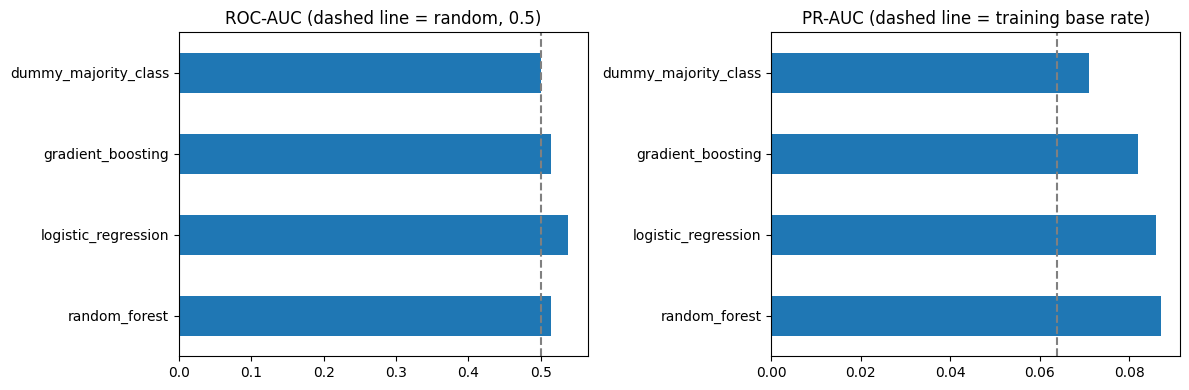

In [42]:
base_rate = y_train.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

summary['roc_auc'].plot.barh(ax=axes[0], title='ROC-AUC (dashed line = random, 0.5)')
axes[0].axvline(0.5, linestyle='--', color='grey')

summary['pr_auc'].plot.barh(ax=axes[1], title='PR-AUC (dashed line = training base rate)')
axes[1].axvline(base_rate, linestyle='--', color='grey')

plt.tight_layout()
plt.show()

**Why these candidates suit this data**

**Constant baseline (`DummyClassifier`)**
It ignores the features and gives every client the training base rate as its score, so it cannot rank anyone. It scores accuracy 0.929 (about 1 minus the average validation positive rate of ~7%), F1 0.000, ROC-AUC 0.500 and PR-AUC 0.071 (the base rate). It is the floor: any useful model must beat it on the ranking metrics. Its high accuracy shows that accuracy alone is misleading on this data, where only about 6% of clients subscribe.

**Logistic regression**
A simple, fast benchmark that outputs probabilities, which can be sorted into a ranked call list. Its coefficients are interpretable, so it shows which client attributes push the score up or down. It works well with the preprocessing already done, because the scaled numeric columns and one-hot categories are the input a linear model expects. Its weakness is that it only captures additive, linear effects on the log-odds, so it cannot model interactions unless they are engineered.

**Random forest (bagging)**
Many decision trees are trained on bootstrap samples and their predictions averaged. This suits the data for several reasons: trees handle mixed categorical and numeric features without scaling, they capture nonlinear patterns and interactions (for example job with age), and they split on thresholds, so skewed counts such as `campaign` and `previous` and their outliers do not distort the model. Averaging many trees reduces variance, which makes one overfitted tree less of a problem. A drawback is that it can still pick up period-specific patterns, which matters here because of drift over time.

**Gradient boosting (boosting)**
Shallow trees are built one after another, each correcting the errors of the previous ones. Boosting is often strong on tabular data because it reduces bias step by step and learns interactions between features, for example month combined with economic conditions, or contact channel combined with previous outcome. Because it keeps fitting the remaining errors, it can overfit noise and period-specific patterns, so the learning rate and tree depth matter, which is why hyperparameter tuning comes later.

**What the results showed**
Under time-ordered CV, all three models are only slightly above the dummy (ROC-AUC 0.514 to 0.538 vs 0.500; PR-AUC 0.082 to 0.087 vs 0.071), and the differences between them are smaller than the fold-to-fold standard deviation (about 0.06 to 0.07). Suitability on paper therefore did not translate into a clear advantage, which the diagnostics section examines.

## Diagnose the weak baseline results

Why this exists: under time-ordered CV, ROC-AUC is about 0.51 to 0.54 for every model, barely above the dummy (0.50). Before moving on, find out whether that is (a) drift over time, (b) time-proxy features such as the economic indicators and month, or (c) a real lack of signal.

**1.Look at each fold separately**

In [43]:
folds = ['fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5']

# ROC-AUC per fold for every model
roc_by_fold_orig = pd.DataFrame(
    {name: res['test_roc_auc'] for name, res in cv_results.items()}, index=folds).round(3)

# PR-AUC relative to the dummy IN THE SAME FOLD (1.0 = no better than the base rate)
dummy_pr = cv_results['dummy_majority_class']['test_pr_auc']
rel_pr = pd.DataFrame(
    {name: res['test_pr_auc'] / dummy_pr
     for name, res in cv_results.items() if 'dummy' not in name}, index=folds).round(2)

display(roc_by_fold_orig)
display(rel_pr)

,dummy_majority_class,logistic_regression,random_forest,gradient_boosting
fold_1,0.5,0.529,0.505,0.514
fold_2,0.5,0.566,0.490,0.532
fold_3,0.5,0.496,0.479,0.475
fold_4,0.5,0.447,0.452,0.435
fold_5,0.5,0.654,0.648,0.616


,logistic_regression,random_forest,gradient_boosting
fold_1,1.02,1.01,1.04
fold_2,1.21,1.07,1.05
fold_3,1.03,0.94,0.93
fold_4,0.94,0.93,0.92
fold_5,1.45,1.62,1.44


Something wrong with fold 4 we need to investigate

**2.Diagnostic only, ordinary shuffled CV on the same training rows**

The question it answers is: are the models bad because the features contain no signal, or because the signal doesn't carry across time?

In [44]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
diag_scoring = {'roc_auc': 'roc_auc', 'pr_auc': 'average_precision'}

shuffled = {}
for name in ['logistic_regression', 'random_forest', 'gradient_boosting']:
    pipe = Pipeline([('prep', preprocess), ('clf', models[name])])
    res = cross_validate(pipe, X_train, y_train, cv=skf, scoring=diag_scoring)
    shuffled[name] = {'roc_auc': res['test_roc_auc'].mean(),
                      'pr_auc': res['test_pr_auc'].mean()}

pd.DataFrame(shuffled).T.round(3)

,roc_auc,pr_auc
logistic_regression,0.670,0.205
random_forest,0.669,0.218
gradient_boosting,0.684,0.210


Shuffled CV scored ROC-AUC 0.67 to 0.68 against 0.51 to 0.54 under time-ordered CV, which rules out a pipeline or label error and suggests the features hold period-specific signal. It is optimistic and not used for model selection or reporting; part of the gap may also reflect larger training sets in shuffled folds.

**3.Feature-set ablation under the SAME time-ordered folds**

The ablation only tested the time-marker features (`month` and the economic indicators); other features that may drift (for example `contact`) were not tested.

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def make_preprocess(num_cols, bin_cols, cat_cols):
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('bin', 'passthrough', bin_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ])

num_no_econ = [c for c in numeric_cols if c not in econ_cols]
cat_no_month = [c for c in categorical_cols if c != 'month']

feature_sets = {
    'all_features':     (numeric_cols, binary_cols, categorical_cols),
    'no_econ':          (num_no_econ,  binary_cols, categorical_cols),
    'no_econ_no_month': (num_no_econ,  binary_cols, cat_no_month),
}

rows, roc_folds = {}, {}
for fs_name, (num, binc, cat) in feature_sets.items():
    prep = make_preprocess(num, binc, cat)
    for m_name in ['logistic_regression', 'random_forest', 'gradient_boosting']:
        pipe = Pipeline([('prep', prep), ('clf', models[m_name])])
        res = cross_validate(pipe, X_train, y_train, cv=tscv, scoring=diag_scoring)
        rows[(fs_name, m_name)] = {'roc_auc': res['test_roc_auc'].mean(),
                                   'pr_auc': res['test_pr_auc'].mean()}
        roc_folds[(fs_name, m_name)] = res['test_roc_auc']

ablation_table = pd.DataFrame(rows).T.round(3)
roc_by_fold = pd.DataFrame(roc_folds, index=folds).round(3)

display(ablation_table)
display(roc_by_fold)

roc_auc  pr_auc
all_features     logistic_regression    0.538   0.086
                 random_forest          0.515   0.087
                 gradient_boosting      0.514   0.082
no_econ          logistic_regression    0.545   0.094
                 random_forest          0.513   0.087
                 gradient_boosting      0.516   0.084
no_econ_no_month logistic_regression    0.523   0.084
                 random_forest          0.505   0.079
                 gradient_boosting      0.508   0.080

all_features                                  \
       logistic_regression random_forest gradient_boosting   
fold_1               0.529         0.505             0.514   
fold_2               0.566         0.490             0.532   
fold_3               0.496         0.479             0.475   
fold_4               0.447         0.452             0.435   
fold_5               0.654         0.648             0.616   

                   no_econ                                  \
       logistic_regression random_forest gradient_boosting   
fold_1               0.527         0.515             0.511   
fold_2               0.567         0.489             0.527   
fold_3               0.501         0.487             0.500   
fold_4               0.456         0.445             0.423   
fold_5               0.677         0.631             0.618   

          no_econ_no_month                                  
       logistic_regression random_forest gradient_boosting  
fold_1               0.515         0.509             0.509  
fold_2               0.566         0.487             0.526  
fold_3               0.494         0.488             0.505  
fold_4               0.442         0.462             0.424  
fold_5               0.597         0.581             0.574

**Diagnostics: why are the baselines near random under time-ordered CV?**

**1. Per-fold ROC-AUC (all features)**
- Folds 1-2 are slightly above 0.5 (0.49 to 0.57), fold 3 is mixed, and fold 5 is clearly above (0.62 to 0.65).
- In fold 4, all three models are below 0.5 (0.435 to 0.452), meaning they rank clients worse than random. Relative PR-AUC in fold 4 is 0.92x to 0.94x of the dummy.
- Fold 5 shows the only real gain (PR-AUC 1.44x to 1.62x the dummy).
- So the mean of about 0.52 hides large swings: patterns learned from earlier records help in some periods and reverse in others.

**2. Shuffled CV (diagnostic only, not a performance estimate)**
- Ignoring time order, ROC-AUC is 0.669 to 0.684 and PR-AUC is 0.205 to 0.218 (about 3.2x to 3.4x the base rate), versus 0.514 to 0.538 under time-ordered CV.
- So the features do carry signal when time is ignored. The gap (~0.13 to 0.17 ROC-AUC) suggests part of that signal depends on the period, so shuffled CV is optimistic and I do not use it for model selection.

**3. Feature-set ablation (same time-ordered folds)**

| Feature set | Logistic reg. | Random forest | Gradient boosting |
|---|---|---|---|
| all features | 0.538 | 0.515 | 0.514 |
| no economic indicators | 0.545 | 0.513 | 0.516 |
| no economic indicators, no month | 0.523 | 0.505 | 0.508 |

(mean ROC-AUC)
- Removing the economic indicators changes ROC-AUC by -0.002 to +0.007, far less than the fold std (0.06 to 0.07). They add nothing measurable.
- Also removing `month` lowers all three models (-0.008 to -0.022), mostly through fold 5 (e.g. logistic regression 0.677 to 0.597). `month` seems to capture period/seasonal differences.
- Fold 4 stays below 0.5 for all 9 model/feature-set combinations (0.42 to 0.46), so it is not explained by the economic indicators or month. The cause is not identified. Possible reasons (untested): a change in the contact strategy or client mix in that period.

**Decision:**

**Final feature set: all features, economic indicators kept.**

 The ablation under time-ordered CV showed no measurable difference when the 5 economic indicators were removed (-0.002 to +0.007 ROC-AUC, versus a fold std of about 0.06 to 0.07), so there is no evidence they hurt. They are publicly known when calls are planned, so they are legitimate pre-call information.

**Limitation:**

they are shared by all clients contacted in the same period, so they mainly identify *when* a call happened, and later periods may take values outside the training range. They are also strongly correlated with one another, which matters for LDA/QDA. Decision based on training-side CV only; I exclude them in Task 2 clustering because there they would group records by period rather than by client characteristics.

# Step 4: Required algorithm studies

**1.Fit LDA, QDA and a regularised QDA on the same folds**

In [46]:
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis)

da_models = {
    'lda': LinearDiscriminantAnalysis(),
    'qda': QuadraticDiscriminantAnalysis(),
    'qda_reg0.5': QuadraticDiscriminantAnalysis(reg_param=0.5),
}

da_means, da_roc_by_fold = {}, {}
for name, clf in da_models.items():
    pipe = Pipeline([('prep', preprocess), ('clf', clf)])
    res = cross_validate(pipe, X_train, y_train, cv=tscv,
                         scoring={'roc_auc': 'roc_auc', 'pr_auc': 'average_precision'})
    da_means[name] = {'roc_auc': res['test_roc_auc'].mean(),
                      'pr_auc': res['test_pr_auc'].mean()}
    da_roc_by_fold[name] = res['test_roc_auc']

display(pd.DataFrame(da_means).T.round(3))
display(pd.DataFrame(da_roc_by_fold, index=['fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5']).round(3))

/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

,roc_auc,pr_auc
lda,0.524,0.083
qda,0.478,0.073
qda_reg0.5,0.541,0.096


,lda,qda,qda_reg0.5
fold_1,0.529,0.535,0.525
fold_2,0.498,0.444,0.506
fold_3,0.496,0.517,0.519
fold_4,0.462,0.451,0.484
fold_5,0.635,0.443,0.671


**Everything in one comparison table**

In [47]:
da_table = pd.DataFrame(da_means).T.round(3)

# 'summary' is your baseline table from Step 3 (all features, same folds)
compare = pd.concat([summary[['roc_auc', 'pr_auc']], da_table]).round(3)
compare.sort_values('roc_auc', ascending=False)

,roc_auc,pr_auc
qda_reg0.5,0.541,0.096
logistic_regression,0.538,0.086
lda,0.524,0.083
random_forest,0.515,0.087
gradient_boosting,0.514,0.082
dummy_majority_class,0.500,0.071
qda,0.478,0.073


**Documenting problems with LDA and QDA**

**What the assignment asks:** if a method struggles with the encoded features or its assumptions, document the problem and do not force it to be the final model.

**Problem 1: plain QDA struggles with the encoded features**
- Evidence: mean ROC-AUC 0.478 (below the dummy's 0.500) and PR-AUC 0.073 (about the dummy's 0.071). Per-fold ROC-AUC is below 0.5 in folds 2, 4 and 5 (0.444, 0.451, 0.443), including fold 5, where the other models do best (0.62 to 0.67).
- Warnings: scikit-learn reported that the covariance matrix of class 0 and of class 1 is not full rank, so QDA's class-specific covariance estimates are unreliable.
- Likely causes (not proven):
  - One-hot encoding makes the levels of each categorical variable add up to 1, which makes columns perfectly dependent.
  - QDA estimates a separate covariance matrix per class, which is many parameters for the small subscriber class (only a couple of hundred subscribers in the early folds).

**Problem 2: both methods assume roughly Gaussian features**
- Most encoded features are 0/1 columns, and counts such as `campaign` and `previous` are skewed, so this assumption does not hold.
- LDA raised no warnings, but its performance (ROC-AUC 0.524) is similar to logistic regression's (0.538) and it is below 0.5 in folds 2, 3 and 4, so its assumptions are probably also a poor match.

**What I tried:** regularised QDA (`reg_param=0.5`), which shrinks the class covariances toward a simpler form. It removed the warnings and raised the scores (ROC-AUC 0.541, PR-AUC 0.096). The value 0.5 was fixed in advance, not tuned.

**Decision:**
- Plain QDA is not used further, since it fails on this data.
- LDA is kept as a diagnostic comparison. It behaves like logistic regression and adds no advantage.
- Regularised QDA's lead over logistic regression (0.003 ROC-AUC) is far smaller than the fold-to-fold std (about 0.06 to 0.07), so I do not choose it because of this table. It remains a candidate for the tuning step, and the final model is chosen under the campaign objective (ranking quality for the call budget), not by these averages.

```
"not full rank" warnings
```

The covariance matrix records how pairs of features vary together within a class. QDA needs to invert it, and redundant columns (one-hot levels that sum to 1, correlated economic indicators) make it singular

reg_param blends it with a simple default (all features independent, equal spread).

QDA needs to "divide by" each class's covariance table (invert it) to measure how far a client is from the class centre, accounting for spread and relationships between features. Redundant columns make the table non-invertible, like dividing by zero, which triggers the "not full rank" warning.

# Step 5: Study imbalance

We compare class weighting and threshold selection

**The idea in simple terms**

1.**Class weighting:** tell the model that a missed subscriber costs more than a false alarm (class_weight='balanced'). This changes the probabilities the model outputs, so at the default 0.5 threshold it flags many more clients. It does not necessarily improve the ranking.

2.**Threshold selection:** a threshold turns a score into a yes/no call. With a 6% base rate, 0.5 is far too high, so almost nobody is flagged (that is why F1 was ~0). Instead of a probability threshold, we use a rank cutoff: flag the top 6% of each validation fold by score. This is the same logic as the bank's fixed call budget, and it does not depend on the base rate drifting.

**Compare plain vs class-weighted models, 0.5 threshold vs top-6% cutoff**

In [48]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score)

TOP_FRAC = 0.06   # flag the top 6% of each validation fold (similar share to 500 calls)

variants = {
    'logreg_plain':    LogisticRegression(max_iter=1000),
    'logreg_balanced': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'rf_plain':        RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                              random_state=RANDOM_STATE, n_jobs=-1),
    'rf_balanced':     RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                              class_weight='balanced_subsample',
                                              random_state=RANDOM_STATE, n_jobs=-1),
}

records = []
for name, clf in variants.items():
    pipe = Pipeline([('prep', preprocess), ('clf', clf)])
    for fold, (tr, va) in enumerate(tscv.split(X_train), start=1):
        pipe.fit(X_train.iloc[tr], y_train.iloc[tr])
        score = pipe.predict_proba(X_train.iloc[va])[:, 1]
        y_va = y_train.iloc[va].to_numpy()

        # (a) default probability threshold 0.5
        pred_05 = (score >= 0.5).astype(int)

        # (b) rank cutoff: flag the top 6% highest scores
        k = int(len(y_va) * TOP_FRAC)
        pred_top = np.zeros(len(y_va), dtype=int)
        pred_top[np.argsort(score)[::-1][:k]] = 1

        records.append({
            'model': name, 'fold': fold,
            'roc_auc': roc_auc_score(y_va, score),
            'pr_auc': average_precision_score(y_va, score),
            'flagged_at_0.5': pred_05.mean(),
            'precision_at_0.5': precision_score(y_va, pred_05, zero_division=0),
            'recall_at_0.5': recall_score(y_va, pred_05, zero_division=0),
            'f1_at_0.5': f1_score(y_va, pred_05, zero_division=0),
            'precision_top6%': precision_score(y_va, pred_top, zero_division=0),
            'recall_top6%': recall_score(y_va, pred_top, zero_division=0),
            'f1_top6%': f1_score(y_va, pred_top, zero_division=0),
            'lift_top6%': precision_score(y_va, pred_top, zero_division=0) / y_va.mean(),
        })

imb = pd.DataFrame(records)

**Summary Tables**

In [49]:
# Mean over the 5 folds, one column per model
display(imb.groupby('model').mean(numeric_only=True).drop(columns='fold').round(3).T)

# Share of clients flagged at the 0.5 threshold, per fold (answers "how many does each model call?")
display(imb.pivot(index='fold', columns='model', values='flagged_at_0.5').round(3))

# Lift of the top-6% cutoff per fold (1.0 = no better than random calling)
display(imb.pivot(index='fold', columns='model', values='lift_top6%').round(2))

model,logreg_balanced,logreg_plain,rf_balanced,rf_plain
roc_auc,0.522,0.538,0.511,0.515
pr_auc,0.082,0.086,0.083,0.087
flagged_at_0.5,0.624,0.069,0.007,0.000
precision_at_0.5,0.058,0.008,0.048,0.000
recall_at_0.5,0.609,0.071,0.006,0.000
f1_at_0.5,0.081,0.014,0.010,0.000
precision_top6%,0.065,0.072,0.087,0.088
recall_top6%,0.052,0.060,0.064,0.060
f1_top6%,0.055,0.062,0.070,0.067
lift_top6%,0.874,0.994,1.068,0.997


model,logreg_balanced,logreg_plain,rf_balanced,rf_plain
fold,,,,
1,0.801,0.346,0.002,0.0
2,0.679,0.000,0.004,0.0
3,0.817,0.000,0.016,0.0
4,0.804,0.000,0.011,0.0
5,0.018,0.000,0.002,0.0


model,logreg_balanced,logreg_plain,rf_balanced,rf_plain
fold,,,,
1,0.63,0.63,0.78,0.63
2,0.90,1.41,1.26,0.95
3,0.87,1.08,0.77,0.62
4,0.95,0.84,0.84,0.84
5,1.02,1.02,1.69,1.95


**Imbalance study: observations**

**What I tried (training rows only, 5 time-ordered folds):**
- Plain vs class-weighted versions of logistic regression and random forest. Class weighting tells the model that missing a subscriber costs more than a false alarm.
- Two ways to decide whom to call: everyone with a score of at least 0.5, or the top 6% by score.

**What I found:**

1. **Class weighting did not improve the ranking.** ROC-AUC went from 0.538 to 0.522 for logistic regression and from 0.515 to 0.511 for random forest. PR-AUC fell slightly too (0.086 to 0.082, and 0.087 to 0.083). These changes are within the normal fold-to-fold noise.

2. **The 0.5 cut-off does not work.** Share of clients flagged: balanced logistic regression 62%, plain logistic regression 7%, balanced random forest 0.7%, plain random forest 0%. Only about 6% of clients subscribe, so tree models almost never reach a score of 0.5, while balanced logistic regression flags most clients.

3. **Balanced logistic regression catches many subscribers only by calling many clients.** Recall is 0.61 but precision is 0.058, about the same as calling at random (the base rate is about 7%).

4. **Plain logistic regression misbehaved in one fold.** It flagged 35% of clients in fold 1 and none in folds 2 to 5. That explains its low accuracy (0.866 vs 0.929 for the dummy). The reason is untested, and extrapolation on features such as the economic indicators is one possibility.

5. **The top-6% rule gives no real lift on average.** Mean lift was 0.87 to 1.07 for all four models (1.0 means no better than random). It was below 1.0 in folds 1 and 4 for every model, and best in fold 5 (random forest 1.95 plain, 1.69 balanced).

6. **The differences between the four variants are small compared with how much results swing between folds.** For example, balanced random forest has the highest mean lift (1.07 vs 1.00 plain), but its lift ranges from 0.77 to 1.69 across folds.

**Decision:**
- Class weighting is not adopted, because it gave no ranking improvement.
- I do not use a probability threshold. The campaign rule is to rank clients by score and call the top k (k = 500), so the final model is judged on lift and precision of the top k.
- The tuning step uses the plain models.

**Not tried:** I did not try SMOTE, due to time. Most of my features are one-hot categorical columns, so synthetic points would need a categorical-aware version (SMOTENC), and it must be applied inside training folds only.

**Limitation:** class imbalance is not the main problem. The models barely rank better than random under time-ordered validation, and results swing between periods, which points to drift over time.

At the 0.5 threshold, balanced models show higher precision and F1 than plain ones (logistic regression: precision 0.058 vs 0.008, F1 0.081 vs 0.014). This is not a real improvement: plain models flag almost nobody (precision counted as 0 where nothing is flagged), while balanced logistic regression flags 62% of clients. Its precision of 0.058 is no better than calling everyone (about 0.07, the base rate). At equal call volume (top 6%), balanced models are no better: logistic regression precision 0.065 vs 0.072 and lift 0.87 vs 0.99; random forest precision 0.087 vs 0.088. Metrics must be compared at the same number of calls, which is why the call-budget cutoff is used.

# Step 6: Tune responsibly

**1.Run the search for each model family**

In [50]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

search_space = {
    'logreg': (LogisticRegression(max_iter=1000),
               {'clf__C': [0.01, 0.1, 1.0]}),
    'rf':     (RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
               {'clf__min_samples_leaf': [5, 25, 100], 'clf__max_depth': [4, 8, None]}),
    'gb':     (GradientBoostingClassifier(random_state=RANDOM_STATE),
               {'clf__learning_rate': [0.03, 0.1], 'clf__max_depth': [2, 3],
                'clf__n_estimators': [100, 200]}),
    'qda':    (QuadraticDiscriminantAnalysis(),
               {'clf__reg_param': [0.1, 0.5, 0.9]}),
}

# Both metrics are recorded; ROC-AUC picks the winner because it is steadier than PR-AUC when the base rate drifts between folds.
tune_scoring = {'roc_auc': 'roc_auc', 'pr_auc': 'average_precision'}

searches = {}
for name, (est, grid) in search_space.items():
    pipe = Pipeline([('prep', preprocess), ('clf', est)])
    gs = GridSearchCV(pipe, grid, cv=tscv, scoring=tune_scoring, refit='roc_auc')
    gs.fit(X_train, y_train)
    searches[name] = gs
    print(f"{name}: best {gs.best_params_}  mean ROC-AUC = {gs.best_score_:.3f}")

logreg: best {'clf__C': 1.0}  mean ROC-AUC = 0.538
rf: best {'clf__max_depth': 4, 'clf__min_samples_leaf': 5}  mean ROC-AUC = 0.520
gb: best {'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__n_estimators': 100}  mean ROC-AUC = 0.525
qda: best {'clf__reg_param': 0.5}  mean ROC-AUC = 0.541


**2.Every candidate, so the full search is visible**

In [51]:
all_results = []
for name, gs in searches.items():
    r = pd.DataFrame(gs.cv_results_)
    r.insert(0, 'model', name)
    all_results.append(r[['model', 'params', 'mean_test_roc_auc',
                          'std_test_roc_auc', 'mean_test_pr_auc']])

tuning_table = pd.concat(all_results, ignore_index=True).round(3)
tuning_table

,model,params,mean_test_roc_auc,std_test_roc_auc,mean_test_pr_auc
0,logreg,{'clf__C': 0.01},0.518,0.076,0.082
1,logreg,{'clf__C': 0.1},0.523,0.071,0.083
2,logreg,{'clf__C': 1.0},0.538,0.070,0.086
3,rf,"{'clf__max_depth': 4, 'clf__min_samples_leaf': 5}",0.520,0.088,0.089
4,rf,"{'clf__max_depth': 4, 'clf__min_samples_leaf':...",0.518,0.084,0.089
5,rf,"{'clf__max_depth': 4, 'clf__min_samples_leaf':...",0.515,0.074,0.083
6,rf,"{'clf__max_depth': 8, 'clf__min_samples_leaf': 5}",0.516,0.079,0.089
7,rf,"{'clf__max_depth': 8, 'clf__min_samples_leaf':...",0.511,0.077,0.085
8,rf,"{'clf__max_depth': 8, 'clf__min_samples_leaf':...",0.515,0.068,0.081
9,rf,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.511,0.067,0.086


**3.Best candidate of each family, judged on the call-budget objective**

In [52]:
def fold_lifts(pipe, frac=0.06):
    """Lift of the top 6% highest-scored clients in each validation fold."""
    lifts = []
    for tr, va in tscv.split(X_train):
        pipe.fit(X_train.iloc[tr], y_train.iloc[tr])
        score = pipe.predict_proba(X_train.iloc[va])[:, 1]
        y_va = y_train.iloc[va].to_numpy()
        top = np.argsort(score)[::-1][:int(len(y_va) * frac)]
        lifts.append(y_va[top].mean() / y_va.mean())
    return np.array(lifts)

best_rows = {}
for name, gs in searches.items():
    lifts = fold_lifts(clone(gs.best_estimator_))   # clone: do not disturb the fitted model
    i = gs.best_index_
    best_rows[name] = {
        'best_params': gs.best_params_,
        'roc_auc': gs.cv_results_['mean_test_roc_auc'][i],
        'roc_auc_std': gs.cv_results_['std_test_roc_auc'][i],
        'pr_auc': gs.cv_results_['mean_test_pr_auc'][i],
        'mean_lift_top6%': lifts.mean(),
        'min_lift': lifts.min(),
        'max_lift': lifts.max(),
    }

best_table = pd.DataFrame(best_rows).T
best_table

,best_params,roc_auc,roc_auc_std,pr_auc,mean_lift_top6%,min_lift,max_lift
logreg,{'clf__C': 1.0},0.53826,0.069833,0.085589,0.993599,0.626739,1.407331
rf,"{'clf__max_depth': 4, 'clf__min_samples_leaf': 5}",0.519862,0.08787,0.089372,1.114642,0.781328,1.95042
gb,"{'clf__learning_rate': 0.03, 'clf__max_depth':...",0.52503,0.06428,0.087792,0.950092,0.391712,1.538665
qda,{'clf__reg_param': 0.5},0.541102,0.066378,0.09557,1.400768,0.66971,2.75226


### Tuning: observations

**Search:** a small grid per model family (23 settings in total), scored on the same 5 time-ordered folds using training rows only. The winner of each family was picked by mean ROC-AUC.

| Model | Best setting | ROC-AUC (std) | PR-AUC | Mean lift of top 6% (min to max) |
|---|---|---|---|---|
| Logistic regression | C = 1.0 | 0.538 (0.070) | 0.086 | 0.99 (0.63 to 1.41) |
| Random forest | depth 4, min leaf 5 | 0.520 (0.088) | 0.089 | 1.11 (0.78 to 1.95) |
| Gradient boosting | learning rate 0.03, depth 3, 100 trees | 0.525 (0.064) | 0.088 | 0.95 (0.39 to 1.54) |
| Regularised QDA | reg_param 0.5 | 0.541 (0.066) | 0.096 | 1.40 (0.67 to 2.75) |

**Observations:**
1. **Tuning changed very little.** Compared with the untuned models, ROC-AUC moved by 0.000 for logistic regression (C = 1.0 is the default), +0.005 for random forest (0.515 to 0.520), +0.011 for gradient boosting (0.514 to 0.525), and 0.000 for QDA (0.5 was already my fixed value). All changes are much smaller than the fold-to-fold std.
2. **All 23 settings are close together** (ROC-AUC 0.507 to 0.541), so the choice of settings matters less than the noise.
3. **More cautious settings tended to do slightly better** for the tree models and QDA: shallow trees (depth 4: 0.515 to 0.520 vs depth None: 0.507 to 0.514), slow learning (0.03: 0.519 to 0.525 vs 0.1: 0.508 to 0.518), and stronger QDA regularisation (reg_param 0.1: 0.510 vs 0.5: 0.541 and 0.9: 0.538). Logistic regression did best with the weakest regularisation, at the edge of my grid, so larger C values were not tested.
4. **Regularised QDA leads on all three measures** (ROC-AUC 0.541, PR-AUC 0.096, mean lift 1.40). The margins are small compared with the fold spread, and its lift ranges from 0.67 to 2.75, so the average may be driven by one or two folds.
5. **Every model has at least one fold with lift below 1.0** (min 0.39 to 0.78), meaning worse than random calling in that period.
6. **Selection bias:** picking the best of several settings on the same folds makes its score slightly optimistic.

**Limitation:** all models rank only slightly better than random under time-ordered validation, so the final choice rests on small, noisy differences.

# Step 7: Final Model

**1.Lift per fold**

This shows lift per fold, so you can see whether QDA's lead comes from one lucky fold

In [53]:
for name, gs in searches.items():
    print(name, fold_lifts(clone(gs.best_estimator_)).round(2))

logreg [0.63 1.41 1.08 0.84 1.02]
rf [0.86 1.06 0.92 0.78 1.95]
gb [0.39 0.9  1.08 0.84 1.54]
qda [0.94 1.31 1.33 0.67 2.75]


**Final model choice**

Per-fold lift of the top 6% (training CV):

| Model | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 | Mean | Median |
|---|---|---|---|---|---|---|---|
| Logistic regression (C=1.0) | 0.63 | 1.41 | 1.08 | 0.84 | 1.02 | 1.00 | 1.02 |
| Random forest (depth 4, min leaf 5) | 0.86 | 1.06 | 0.92 | 0.78 | 1.95 | 1.11 | 0.92 |
| Gradient boosting (lr 0.03, depth 3, 100 trees) | 0.39 | 0.90 | 1.08 | 0.84 | 1.54 | 0.95 | 0.90 |
| Regularised QDA (reg_param=0.5) | 0.94 | 1.31 | 1.33 | 0.67 | 2.75 | 1.40 | 1.31 |

**Choice: regularised QDA (reg_param=0.5)**, selected for the call-budget objective (lift of the top-k), not accuracy. It has the highest mean and median lift, is best in 3 of 5 folds, and remains best (1.06) when fold 5 is excluded, though only just above 1.0. In fold 5, roughly 127 subscribers were found in the top 6% against about 46 expected at random, far beyond chance.

**Choice: on reg_param** In tuning table, 0.5 and 0.9 were nearly tied (ROC-AUC 0.541 vs 0.538), and 0.9 had the higher PR-AUC (0.101 vs 0.096).Picked 0.5 because ROC-AUC was the pre-set selection metric, and the gap is within noise.

**Caveats:** its Gaussian assumptions do not fit one-hot features, so it is chosen for ranking performance, not model fit; reg_param was searched over three values only; lift is below 1.0 in folds 1 and 4 (worst in fold 4 at 0.67); five folds give a noisy estimate, and most fold-to-fold differences are within chance. Differences between models are mostly small relative to this noise.

The assignment says to choose the final model by the campaign objective, which is lift and precision in the top-k. On that rule, regularised QDA is the natural pick

**2.Fix the final model (still no holdout)**

In [54]:
chosen = 'qda'

# GridSearchCV already refit the best settings on ALL of X_train.
final_pipe = searches[chosen].best_estimator_
print("Final model:", chosen, searches[chosen].best_params_)

Final model: qda {'clf__reg_param': 0.5}


Final model chosen using training-side cross-validation only; the holdout had not been scored at this point.

# Step 8: Evaluate, Error analysis

**1.Score the holdout once and compute the headline numbers**

In [55]:
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, f1_score)
import matplotlib.pyplot as plt

K = 500                                    # call budget
y_h = y_holdout.to_numpy()
holdout_scores = final_pipe.predict_proba(X_holdout)[:, 1]    # the one and only scoring

base_rate = y_h.mean()
order = np.argsort(-holdout_scores, kind='stable')   # best score first
top_idx = order[:K]                                  # the 500 clients we would call
pred_top = np.zeros(len(y_h), dtype=int)
pred_top[top_idx] = 1

hits = int(y_h[top_idx].sum())
precision_k = hits / K
recall_k = hits / y_h.sum()
lift_k = precision_k / base_rate

results = pd.Series({
    'holdout rows': len(y_h),
    'holdout subscribers': int(y_h.sum()),
    'base rate (= precision of a random ranking)': round(base_rate, 4),
    'random ranking: expected subscribers in 500 calls': round(K * base_rate, 1),
    'precision@500': round(precision_k, 4),
    'subscribers in top 500 (hits)': hits,
    'recall@500': round(recall_k, 4),
    'F1@500': round(f1_score(y_h, pred_top), 4),
    'lift@500 (precision@500 / base rate)': round(lift_k, 3),
    'ROC-AUC (whole holdout)': round(roc_auc_score(y_h, holdout_scores), 4),
    'PR-AUC (whole holdout)': round(average_precision_score(y_h, holdout_scores), 4),
})
results

,0
holdout rows,8236.0000
holdout subscribers,2539.0000
base rate (= precision of a random ranking),0.3083
random ranking: expected subscribers in 500 calls,154.1000
precision@500,0.6400
subscribers in top 500 (hits),320.0000
recall@500,0.1260
F1@500,0.2106
lift@500 (precision@500 / base rate),2.0760
ROC-AUC (whole holdout),0.6598


**2.Are there ties at the cutoff? and the confusion matrix**

In [56]:
# If many clients share the same score at rank 500, the top-500 choice is partly arbitrary.
cutoff_score = holdout_scores[top_idx[-1]]
print("score at rank 500:", round(cutoff_score, 6),
      "| clients tied at that score:", int((holdout_scores == cutoff_score).sum()),
      "| distinct scores overall:", len(np.unique(holdout_scores)))

cm = confusion_matrix(y_h, pred_top)
pd.DataFrame(cm, index=['actual: no', 'actual: yes'], columns=['not called', 'called (top 500)'])

score at rank 500: 1.0 | clients tied at that score: 816 | distinct scores overall: 7165


,not called,called (top 500)
actual: no,5517,180
actual: yes,2219,320


**3.Evaluation plots**

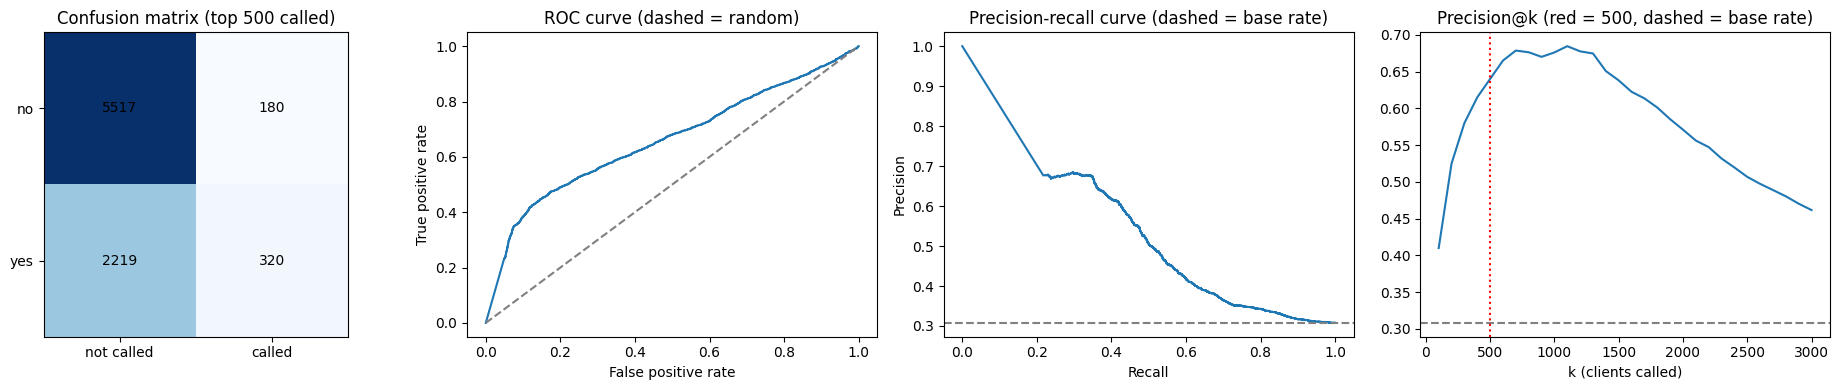

In [57]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['not called', 'called'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['no', 'yes'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center')
axes[0].set_title('Confusion matrix (top 500 called)')

fpr, tpr, _ = roc_curve(y_h, holdout_scores)
axes[1].plot(fpr, tpr); axes[1].plot([0, 1], [0, 1], '--', color='grey')
axes[1].set_title('ROC curve (dashed = random)')
axes[1].set_xlabel('False positive rate'); axes[1].set_ylabel('True positive rate')

prec, rec, _ = precision_recall_curve(y_h, holdout_scores)
axes[2].plot(rec, prec); axes[2].axhline(base_rate, linestyle='--', color='grey')
axes[2].set_title('Precision-recall curve (dashed = base rate)')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')

ks = np.arange(100, 3001, 100)
axes[3].plot(ks, [y_h[order[:k]].mean() for k in ks])
axes[3].axhline(base_rate, linestyle='--', color='grey')
axes[3].axvline(K, linestyle=':', color='red')
axes[3].set_title('Precision@k (red = 500, dashed = base rate)')
axes[3].set_xlabel('k (clients called)')

plt.tight_layout()
plt.show()

**4.The top-500 table**

In [58]:
top500 = pd.DataFrame({
    'rank': np.arange(1, K + 1),
    'holdout_row': X_holdout.index[top_idx],   # row position in the de-duplicated file, NOT a customer ID
    'predicted_score': holdout_scores[top_idx],
    'historical_outcome': y_h[top_idx],        # 1 = subscribed, 0 = did not
})
top500.to_csv('top500_holdout.csv', index=False)
top500.head(10)

,rank,holdout_row,predicted_score,historical_outcome
0,1,44,1.0,0
1,2,88,1.0,0
2,3,227,1.0,0
3,4,239,1.0,0
4,5,300,1.0,0
5,6,432,1.0,1
6,7,436,1.0,1
7,8,440,1.0,0
8,9,481,1.0,0
9,10,519,1.0,0


**5.How the holdout differs from training**

In [59]:
print("train base rate:", round(y_train.mean(), 3), "| holdout base rate:", round(base_rate, 3))

print(pd.DataFrame({'train': X_train['month'].value_counts(normalize=True),
                    'holdout': X_holdout['month'].value_counts(normalize=True)}).fillna(0).round(3))

print(X_train[econ_cols].agg(['min', 'max']).round(2))
print(X_holdout[econ_cols].agg(['min', 'max']).round(2))

for c in categorical_cols:
    unseen = set(X_holdout[c]) - set(X_train[c])
    if unseen:
        print("categories in holdout but never in training:", c, unseen)

train base rate: 0.064 | holdout base rate: 0.308
       train  holdout
month                
apr    0.075    0.021
aug    0.157    0.122
dec    0.000    0.021
jul    0.203    0.059
jun    0.133    0.115
mar    0.009    0.032
may    0.312    0.423
nov    0.110    0.059
oct    0.002    0.079
sep    0.000    0.069
     emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed
min          -1.8           92.76          -50.0       1.30       5099.1
max           1.4           94.46          -36.1       5.04       5228.1
     emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed
min          -3.4           92.20          -50.8       0.63       4963.6
max          -1.1           94.77          -26.9       1.30       5099.1
categories in holdout but never in training: month {'sep'}


**6.Error analysis (where does the top 500 go wrong?)**

In [60]:
view = X_holdout.copy()
view['y'] = y_h
view['flagged'] = pred_top

# For each feature: precision inside the called group (false-positive patterns)
# and recall among real subscribers (false-negative patterns).
for col in ['month', 'contact', 'poutcome', 'job']:
    called = view[view.flagged == 1].groupby(col)['y'].agg(n_called='size', precision='mean')
    subs = view[view.y == 1].groupby(col)['flagged'].agg(n_subscribers='size', recall='mean')
    display(called.join(subs, how='outer').round(3))

view['group'] = np.select(
    [(pred_top == 1) & (y_h == 1), (pred_top == 1) & (y_h == 0), (pred_top == 0) & (y_h == 1)],
    ['TP', 'FP', 'FN'], default='TN')
view.groupby('group')[['age', 'campaign', 'previous']].median()

,n_called,precision,n_subscribers,recall
month,,,,
apr,46,0.717,97,0.340
aug,62,0.629,384,0.102
dec,45,0.689,88,0.352
jul,10,0.700,241,0.029
jun,61,0.689,371,0.113
mar,64,0.750,150,0.320
may,102,0.500,453,0.113
nov,49,0.612,226,0.133
oct,51,0.667,273,0.125


,n_called,precision,n_subscribers,recall
contact,,,,
cellular,465,0.641,2331,0.128
telephone,35,0.629,208,0.106


,n_called,precision,n_subscribers,recall
poutcome,,,,
failure,78.0,0.526,480,0.085
nonexistent,NaN,NaN,1228,0.000
success,422.0,0.661,831,0.336


,n_called,precision,n_subscribers,recall
job,,,,
admin.,164,0.646,793,0.134
blue-collar,42,0.476,216,0.093
entrepreneur,6,0.167,45,0.022
housemaid,18,0.722,67,0.194
management,36,0.556,169,0.118
retired,58,0.776,321,0.140
self-employed,11,0.545,68,0.088
services,18,0.722,145,0.090
student,52,0.712,215,0.172


,age,campaign,previous
group,,,
FN,37.0,0.0,0.0
FP,36.0,0.5,1.0
TN,35.0,1.0,0.0
TP,38.0,0.0,1.0


**Final evaluation on the holdout (scored once)**

**Model:** regularised QDA (reg_param = 0.5), chosen on training-side time-ordered CV only, before the holdout was scored.

**Headline results (k = 500 calls)**

| Measure | Value |
|---|---|
| Holdout rows / subscribers | 8,236 / 2,539 |
| Base rate (= precision of a random ranking) | 0.308 (training rows: 0.064) |
| Subscribers a random 500 calls would find | about 154 |
| Subscribers found in the top 500 | 320 |
| **precision@500** | **0.640** |
| recall@500 | 0.126 (the maximum possible is 500 / 2,539 = 0.197) |
| F1@500 | 0.211 |
| **lift@500** | **2.08** (the maximum possible is 1 / 0.308 = 3.24) |
| ROC-AUC (whole holdout) | 0.660 |
| PR-AUC (whole holdout) | 0.510 (random ranking: 0.308) |

**Confusion matrix (top 500 called):** TN 5,517, FP 180, FN 2,219, TP 320.

**Why accuracy alone misleads:** this rule has accuracy (5,517 + 320) / 8,236 = 0.709, while calling nobody scores 0.692 (the share of non-subscribers). Accuracy barely distinguishes the two, although the model finds 320 subscribers where random calling would find about 154. The bank's goal is finding subscribers within a fixed budget, so precision@500 and lift@500 are the relevant measures. Recall@500 looks low (0.126), but even a perfect model could not exceed 0.197, because only 500 of 2,539 subscribers can be called. About 2,039 misses are therefore unavoidable, and only about 180 (equal to the FP count) are avoidable.

**Compared with cross-validation**

Training-side CV for this model gave ROC-AUC 0.541 and mean lift 1.40 (range 0.67 to 2.75). On the holdout, ROC-AUC is 0.660 and lift@500 is 2.08. These are not directly comparable, because the base rate is 30.8% on the holdout against 4% to 14% in the CV folds. The pattern is consistent with the CV result that the model worked best in the most recent fold (fold 5, lift 2.75). Why later periods are easier is not tested.

**How the holdout differs from training (observations only, nothing changed because of them)**

- **Base rate:** 30.8% vs 6.4%, almost five times higher.
- **Economic indicators:** the holdout lies largely outside the training range. For example, `euribor3m` is 0.63 to 1.30 in the holdout and 1.30 to 5.04 in training; `nr.employed` is 4,963.6 to 5,099.1 vs 5,099.1 to 5,228.1. The model is therefore extrapolating on these features.
- **Months:** September never appears in training, December is essentially absent, and October (0.2%) and March (0.9%) are rare, while they make up 6.9%, 2.1%, 7.9% and 3.2% of the holdout.

**Ties at the top of the ranking (limitation)**

QDA's probabilities are saturated: **816 clients share the maximum score of 1.0**, and all 500 called clients are among them. Scores 1 to 500 are therefore not a true ranking; ties were broken by position in the file (earliest rows first). Consequences:
- The exact precision@500 depends on which 500 of the 816 are picked. I report the tie-break as used and did not change it after seeing results.
- The left part of the precision@k curve (up to about k = 800) reflects this file order, not model ranking. The straight segment at the start of the precision-recall curve is the same effect.
- A real deployment would need a second ranking among tied clients (not tested here).

**Error analysis**

**False positives (180 called clients who did not subscribe)**
1. **May.** 102 clients were called in May (20% of the list) with precision 0.500, compared with 0.640 overall. That is about 51 of the 180 false positives. *Consequence:* the biggest block of wasted calls comes from the month with the lowest hit rate, and May is also 42% of all holdout records.
2. **Previous campaign failed.** 78 called clients had `poutcome = failure`, with precision 0.526, against 0.661 for the 422 called clients with `poutcome = success`. About 37 of the false positives come from the failure group, which makes up only 16% of the calls. *Consequence:* calls to clients who declined last time pay off less often.
- Other segments have too few calls to read (for example entrepreneurs: 6 called, precision 0.167).

**False negatives (2,219 missed subscribers)**
1. **No previous campaign contact.** 1,228 subscribers (48% of all) have `poutcome = nonexistent`, and none were called (recall 0.000). *Consequence:* the list contains only clients with a past campaign outcome (84% of calls are previous successes). The bank would find no new customers this way, and would miss nearly half of all subscribers.
2. **July and September.** Recall is 0.029 for July (241 subscribers) and 0.020 for September (256 subscribers), with only 10 clients called in each. September was never seen in training. *Consequence:* months that are rare or absent in training get almost no calls, although they contain many subscribers.
- Median `previous` is 0 for false negatives (like true negatives) and 1 for false positives and true positives. Median age is 35 to 38 in all four groups, so there is no age pattern.

**Limitations**
- Offline demonstration on historical records. The data does not show that calling someone causes a subscription.
- One holdout period with a very different base rate and economic conditions. Precision@500 has a rough sampling error of about ±0.04 (95%), ignoring the tie-break effect.
- The ranking rests largely on past campaign outcome (`poutcome`), and ties at score 1.0 make the top 500 partly arbitrary.
- Lift@500 is not comparable with CV lift, because the base rates differ.

# Export data for Task 2

In [61]:
from google.colab import files
pd.DataFrame({'score': holdout_scores,
              'y': y_h,
              'in_top500': pred_top}).to_csv('holdout_scores.csv', index=False)
files.download('holdout_scores.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>